# ABDELLOU--GENESTIER Renaud LAFARGE Baptiste
### La violence des jeunes américains est-elle correllée par une industrie du jeu vidéo orientée sur la violence ?

## Comphréhension Présentation des données

Notre objectif est de chercher une potentielle correlation entre les violences commise dans les écoles au etat-unis. Mais aussi de chercher si les éditeurs de jeux videos propose de plus en plus de jeux violent. On definie un jeu comme violent A CHANGEr si sont theme et guerre/violence/autre

pour cela on a deux dataset une sur les tueries au états unis de 1999 jusqu'en 2025. L'autre montre tout les jeux sortie entre A CHANGER 1985 et 2025 avec plein d'information l'editeur le type de jeu le score critique,le type de jeu, le nombre de vente selon le continent et plus

## Nettoyage des données
pour les datasets on s'assure que chaque colonne est complète sans valeur exageré avant de l'exporter dans une base sql afin d'avoir un requêtage propre. 

Pour le data set jeu video on va retirer une colonne qui ne sert a rien la première img qui est sensé montrer la jacquette du jeu comme on n'a pas les images elle alourdie le data set pour rien

In [1]:
import pandas as pd

# Load the dataset
# Adjust the filename extension if your file is named differently (e.g., .xlsx)
df = pd.read_csv('school-shootings-data.csv')

# Define the columns to drop
columns_to_drop = [
    'nces_school_id', 
    'nces_district_id', 
    'lunch', 
    'state_fips', 
    'county_fips', 
    'ulocale'
]

# Drop the columns
# errors='ignore' prevents an error if a column is already missing
df_cleaned = df.drop(columns=columns_to_drop, errors='ignore')

# Display the first few rows to verify the columns are gone
df_cleaned.head()


,uid,school_name,district_name,date,school_year,year,time,day_of_week,city,state,...,two_or_more,resource_officer,weapon,weapon_source,lat,long,staffing,low_grade,high_grade,county
0,1,Columbine High School,Jefferson County R-1,4/20/1999,1998-1999,1999,11:19 AM,Tuesday,Littleton,Colorado,...,NaN,1.0,12-gauge Savage-Springfield 67H pump-action sh...,purchased from friends,39.603910,-105.075000,89.6,9,12,Jefferson County
1,2,Scotlandville Middle School,East Baton Rouge Parish School Board,4/22/1999,1998-1999,1999,12:30 PM,Thursday,Baton Rouge,Louisiana,...,NaN,0.0,.22 caliber pistol,NaN,30.529958,-91.169966,39.0,6,8,East Baton Rouge Parish
2,3,Heritage High School,Rockdale County,5/20/1999,1998-1999,1999,8:03 AM,Thursday,Conyers,Georgia,...,NaN,1.0,".22 caliber rifle, 357-caliber Magnum handgun",NaN,33.626922,-84.047960,84.0,9,12,Rockdale County
3,4,John Bartram High School,Philadelphia City SD,10/4/1999,1999-2000,1999,10:00 AM,Monday,Philadelphia,Pennsylvania,...,NaN,1.0,RG .25-caliber pistol,purchased from friend,39.921509,-75.234108,41.0,9,12,Philadelphia County
4,5,Dorchester High School,Boston,11/3/1999,1999-2000,1999,7:40 AM,Wednesday,Boston,Massachusetts,...,NaN,0.0,NaN,NaN,42.285268,-71.075901,NaN,9,12,Suffolk County


In [2]:
import pandas as pd

# Define the path to your CSV file
file_path = '/home/r/Work/Licence/big_data/projet2/vgchartz-2024.csv'

# Load the dataset into a pandas DataFrame
try:
    df = pd.read_csv(file_path)

    # Define the list of columns to be removed for clarity and reusability
    columns_to_drop = [
        'img', 
        'jp_sales', 
        'pal_sales', 
        'other_sales', 
        'last_update'
    ]

    # Drop the specified columns from the DataFrame
    # Using errors='ignore' will prevent the code from failing if a column doesn't exist
    df_cleaned = df.drop(columns=columns_to_drop, errors='ignore')

    # Display the first 5 rows of the cleaned DataFrame to verify the changes
    print("Cleaned DataFrame head:")
    print(df_cleaned.head())

    # Display the new column list to confirm removal
    print("\nRemaining columns:")
    print(df_cleaned.columns.tolist())

except FileNotFoundError:
    print(f"Error: The file was not found at {file_path}")
except Exception as e:
    print(f"An error occurred: {e}")


Error: The file was not found at /home/r/Work/Licence/big_data/projet2/vgchartz-2024.csv


In [3]:
import pandas as pd
import sqlite3

# Define file paths (assuming files are in the current working directory)
school_file = 'school-shootings-data.csv'
vg_file = 'vgchartz-2024.csv'

# 1. Load and Clean School Shootings Data
try:
    df_school = pd.read_csv(school_file)
    school_cols_to_drop = [
        'nces_school_id', 'nces_district_id', 'lunch', 
        'state_fips', 'county_fips', 'ulocale'
    ]
    df_school_cleaned = df_school.drop(columns=school_cols_to_drop, errors='ignore')
    print(f"Loaded {school_file} and dropped {len(school_cols_to_drop)} columns.")
except FileNotFoundError:
    print(f"Error: {school_file} not found.")
    df_school_cleaned = pd.DataFrame() # Empty DF to prevent crash

# 2. Load and Clean VGChartz Data
try:
    df_vg = pd.read_csv(vg_file)
    vg_cols_to_drop = ['img', 'jp_sales', 'pal_sales', 'other_sales', 'last_update']
    df_vg_cleaned = df_vg.drop(columns=vg_cols_to_drop, errors='ignore')
    print(f"Loaded {vg_file} and dropped {len(vg_cols_to_drop)} columns.")
except FileNotFoundError:
    print(f"Error: {vg_file} not found.")
    df_vg_cleaned = pd.DataFrame()

# 3. Create SQLite Database and Write Tables
db_name = 'data.db'
conn = sqlite3.connect(db_name)

if not df_school_cleaned.empty:
    df_school_cleaned.to_sql('school_shootings', conn, if_exists='replace', index=False)
    print(f"Table 'school_shootings' created in {db_name}")

if not df_vg_cleaned.empty:
    df_vg_cleaned.to_sql('video_games', conn, if_exists='replace', index=False)
    print(f"Table 'video_games' created in {db_name}")

conn.close()
print("Database operations complete.")


Loaded school-shootings-data.csv and dropped 6 columns.
Loaded vgchartz-2024.csv and dropped 5 columns.
Table 'school_shootings' created in data.db
Table 'video_games' created in data.db
Database operations complete.


## Analyse de la table video_games


le type de jeu le plus sortie chaque année

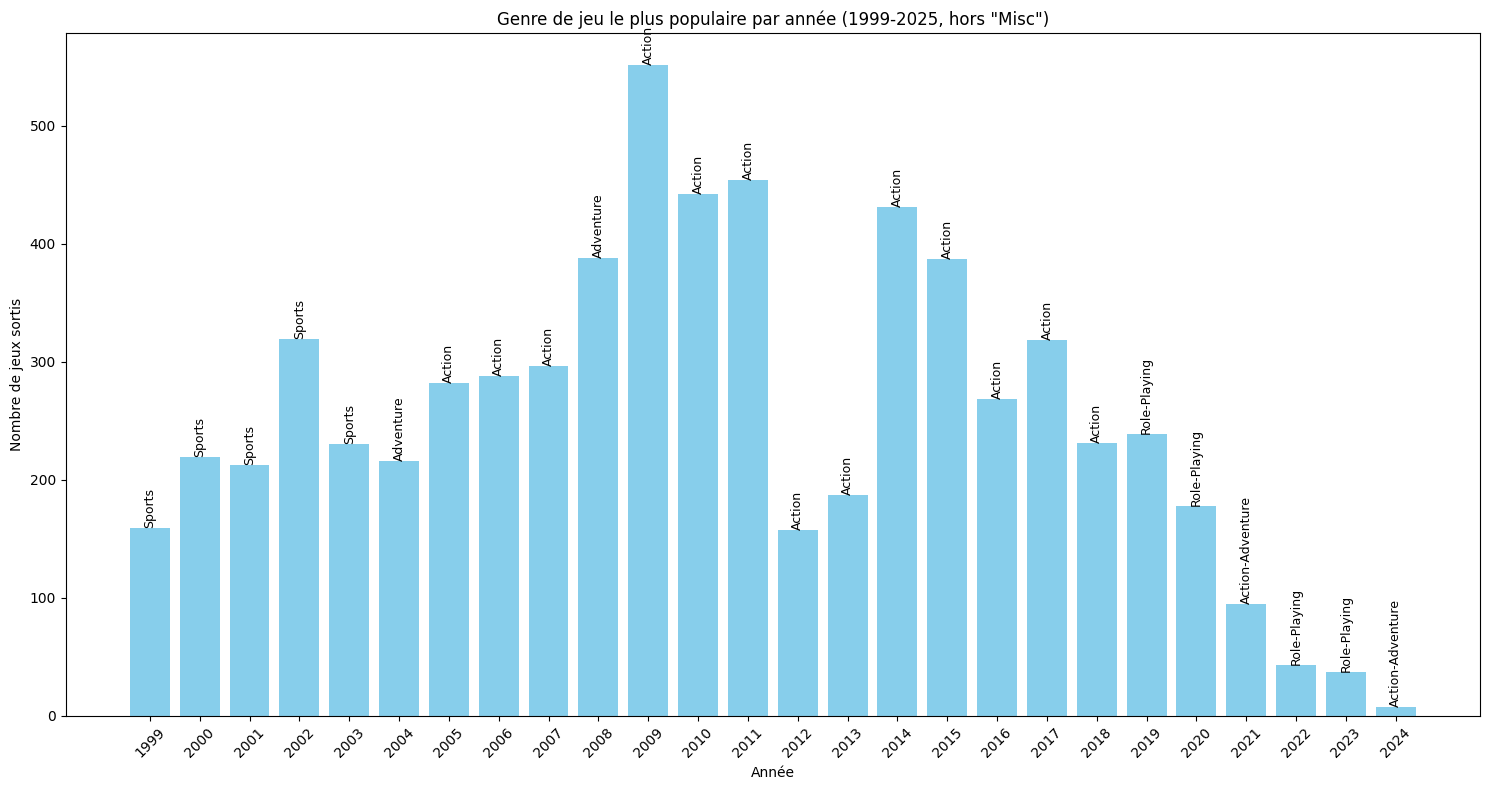

In [ ]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

# 1. Connexion à la base de données
conn = sqlite3.connect('./data.db')

# 2. Requête SQL pour extraire les données brutes
query = """
SELECT 
    strftime('%Y', release_date) AS year, 
    genre, 
    COUNT(*) AS count 
FROM video_games 
WHERE release_date IS NOT NULL AND genre IS NOT NULL
GROUP BY year, genre
"""

# 3. Charger les données dans un DataFrame pandas
df = pd.read_sql_query(query, conn)


# On garde les années entre 1999 et 2025
df = df[(df['year'] >= '1999') & (df['year'] <= '2025')]

# On enlève la catégorie 'Misc' (insensible à la casse pour plus de sécurité)
df = df[df['genre'].str.lower() != 'misc']


# 5. Trouver le genre le plus fréquent pour chaque année
top_genres_per_year = df.sort_values(['year', 'count'], ascending=[True, False]).groupby('year').first().reset_index()

# 6. Création du graphique à barres
plt.figure(figsize=(15, 8))
bars = plt.bar(top_genres_per_year['year'], top_genres_per_year['count'], color='skyblue')

# Ajouter les noms des genres au-dessus des barres
for bar, genre in zip(bars, top_genres_per_year['genre']):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, genre, 
             ha='center', va='bottom', rotation=90, fontsize=9)

plt.xlabel('Année')
plt.ylabel('Nombre de jeux sortis')
plt.title('Genre de jeu le plus populaire par année (1999-2025, hors "Misc")')
plt.xticks(rotation=45)
plt.tight_layout()

# Afficher le graphique
plt.show()


Dans la majorité des années c'est action le plus important probablement jeux violent :!!!!

C:\Users\babla\AppData\Local\Temp\ipykernel_2828\2275765298.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('YlOrRd')(norm(top_sales['total_sales'])) # Dégradé Jaune à Rouge


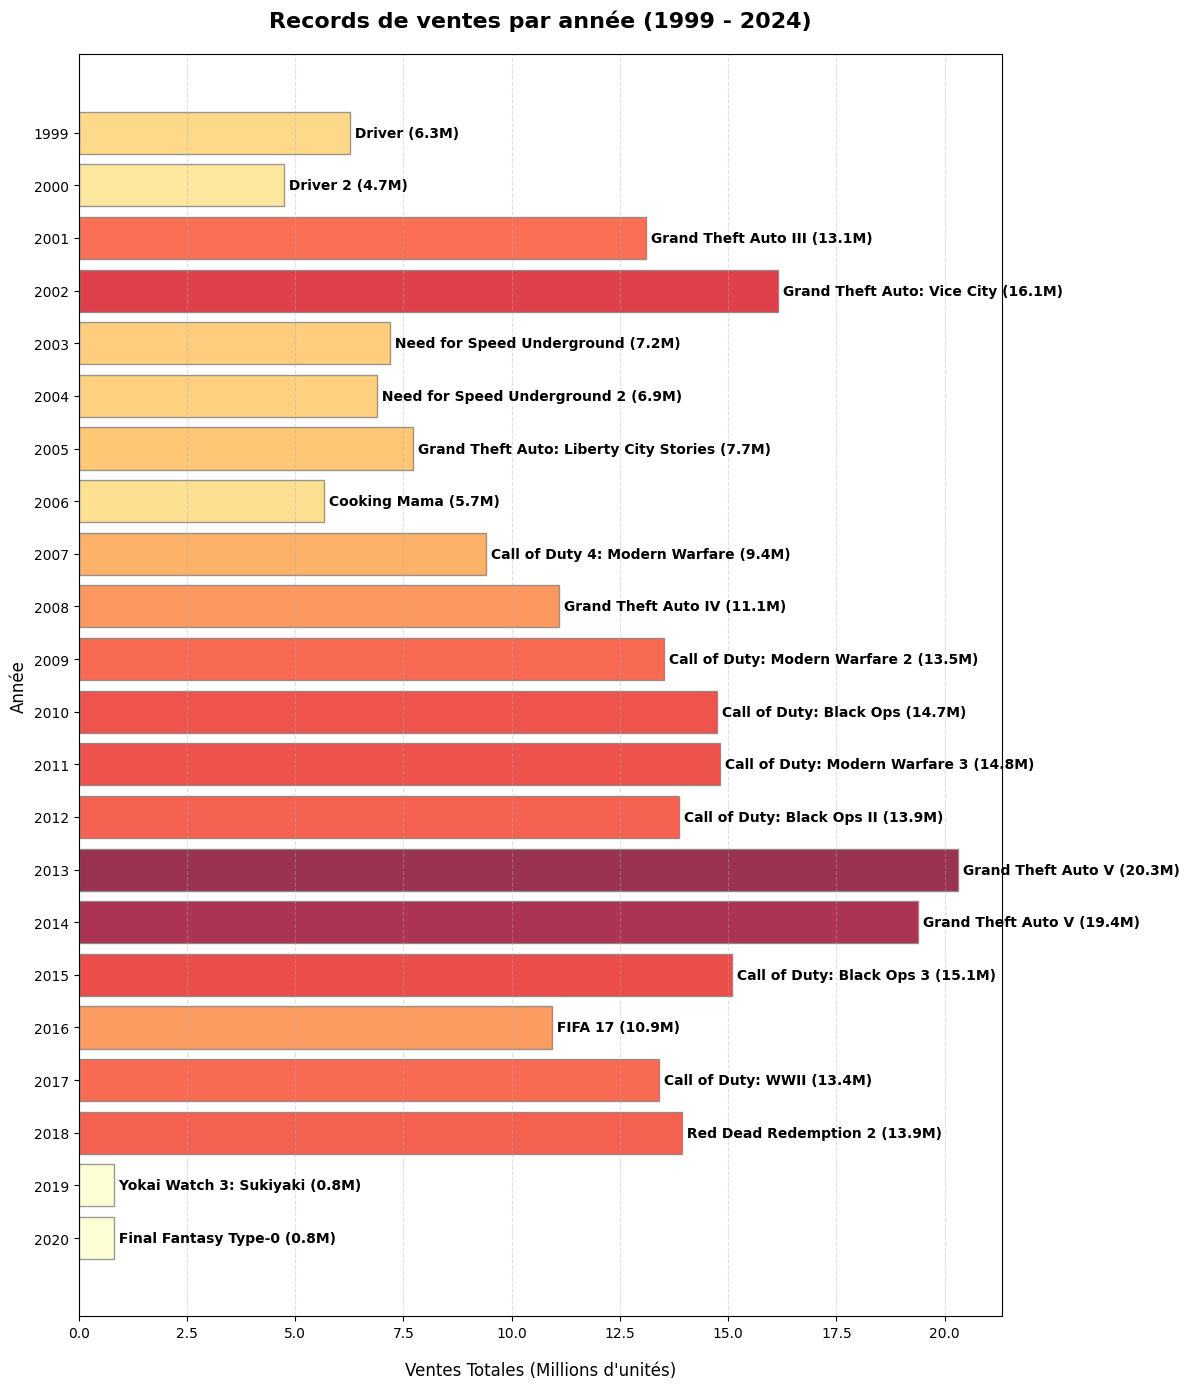

In [17]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import matplotlib.cm as cm # Pour le dégradé de couleurs

# 1. Connexion et extraction (inchangé)
conn = sqlite3.connect('./data.db')
query = """
SELECT 
    title, 
    strftime('%Y', release_date) AS year, 
    total_sales 
FROM video_games 
WHERE year BETWEEN '1999' AND '2024' AND total_sales IS NOT NULL
"""
df = pd.read_sql_query(query, conn)
conn.close()

# 2. Préparation des données
df['year'] = df['year'].astype(int)
top_sales = df.sort_values(['year', 'total_sales'], ascending=[True, False]).groupby('year').head(1)

# 3. Création du graphique horizontal
plt.figure(figsize=(12, 14)) # Plus haut pour espacer les années

# Création d'un dégradé de couleur basé sur les ventes
norm = plt.Normalize(top_sales['total_sales'].min(), top_sales['total_sales'].max())
colors = cm.get_cmap('YlOrRd')(norm(top_sales['total_sales'])) # Dégradé Jaune à Rouge

bars = plt.barh(top_sales['year'].astype(str), top_sales['total_sales'], color=colors, edgecolor='grey', alpha=0.8)


for i, bar in enumerate(bars):
    width = bar.get_width()
    label_text = f" {top_sales.iloc[i]['title']} ({width:.1f}M)"
    
    # On place le texte à droite de la barre
    plt.text(width, bar.get_y() + bar.get_height()/2, 
             label_text, 
             va='center', ha='left', fontsize=10, fontweight='bold')

# 5. Esthétique finale
plt.xlabel('Ventes Totales (Millions d\'unités)', fontsize=12, labelpad=15)
plt.ylabel('Année', fontsize=12)
plt.title('Records de ventes par année (1999 - 2024)', fontsize=16, fontweight='bold', pad=20)
plt.grid(axis='x', linestyle='--', alpha=0.4) # Grille verticale uniquement
plt.gca().invert_yaxis() # Inverser pour avoir 1999 en haut
plt.tight_layout()

plt.show()

A VOIR POUR FAIRE PLUS BEAU que des COD ou GTA ou driver derivé de gta des jeux typé violent fifa en 2017 pas du tout violent cooking mama pas du tout violent
A partir de 2019 manque de donnée sur les ventes car vente pas partagé par la pluspart des editeurs

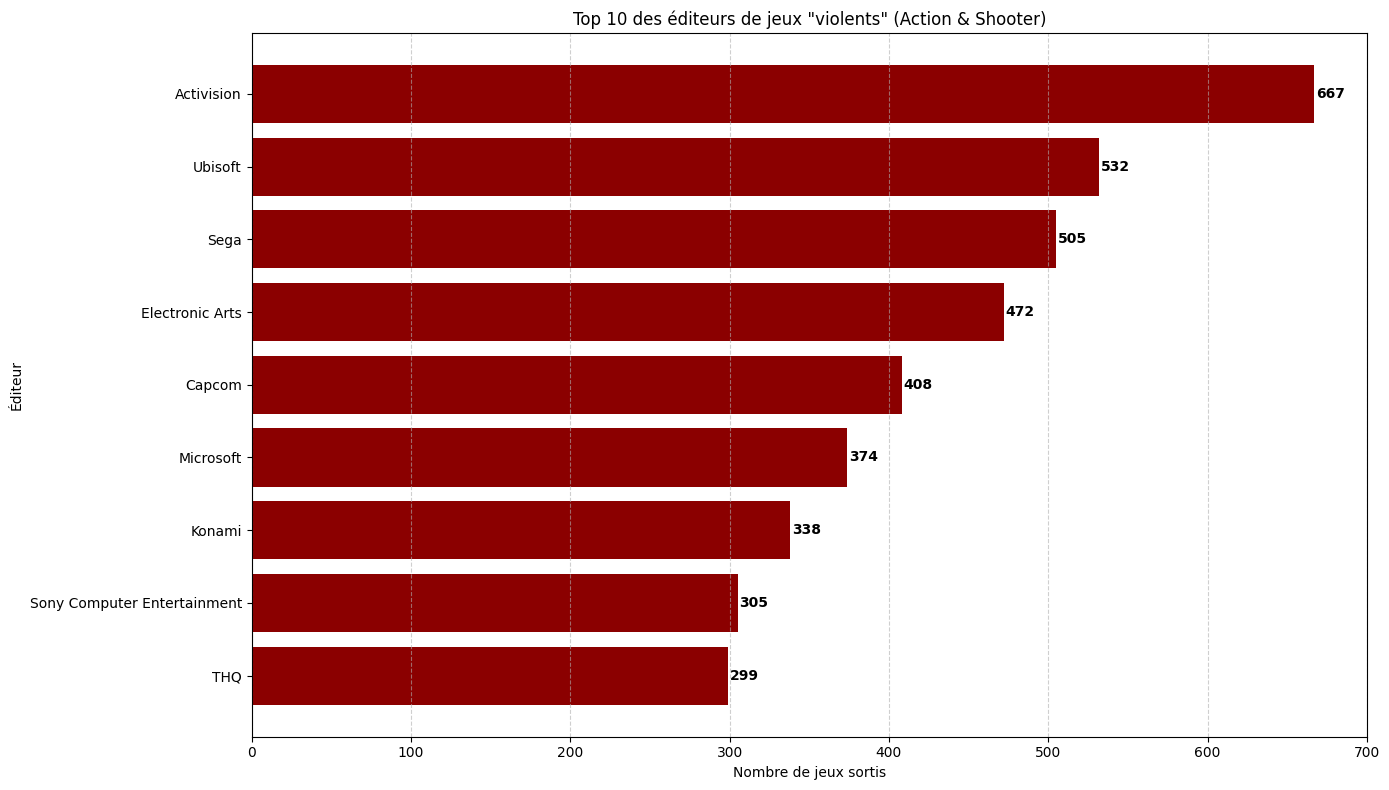

In [10]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

# 1. Connexion à la base de données
conn = sqlite3.connect('./data.db')
# 2. Requête SQL pour compter les jeux par éditeur dans les genres spécifiques
# On inclut Action, Shooter et Action-Adventure
query = """
SELECT
    publisher,
    COUNT(*) AS game_count
FROM video_games
WHERE genre IN ('Action', 'Shooter', 'Action-Adventure')
AND publisher IS NOT NULL
GROUP BY publisher
ORDER BY game_count DESC
LIMIT 10
"""
# 3. Charger les données dans un DataFrame pandas
df = pd.read_sql_query(query, conn)
df = df[df['publisher'].str.lower() != 'unknown']
# 4. Création du graphique à barres
plt.figure(figsize=(14, 8))
# On utilise barh (horizontal) pour mieux lire les noms des éditeurs
bars = plt.barh(df['publisher'], df['game_count'], color='darkred')
# Ajouter le nombre exact à côté de chaque barre
for i, v in enumerate(df['game_count']):
    plt.text(v + 1, i, str(int(v)), va='center', fontweight='bold')
plt.xlabel('Nombre de jeux sortis')
plt.ylabel('Éditeur')
plt.title('Top 10 des éditeurs de jeux "violents" (Action & Shooter)')
plt.gca().invert_yaxis()  # Mettre le premier du classement en haut
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
# Afficher le graphique
plt.show()
# Fermer la connexion
conn.close()

en 26 en compte plusieurs milliers de jeux violent activison et ubisoft en premier connu notamment pour COD et assassin creed 

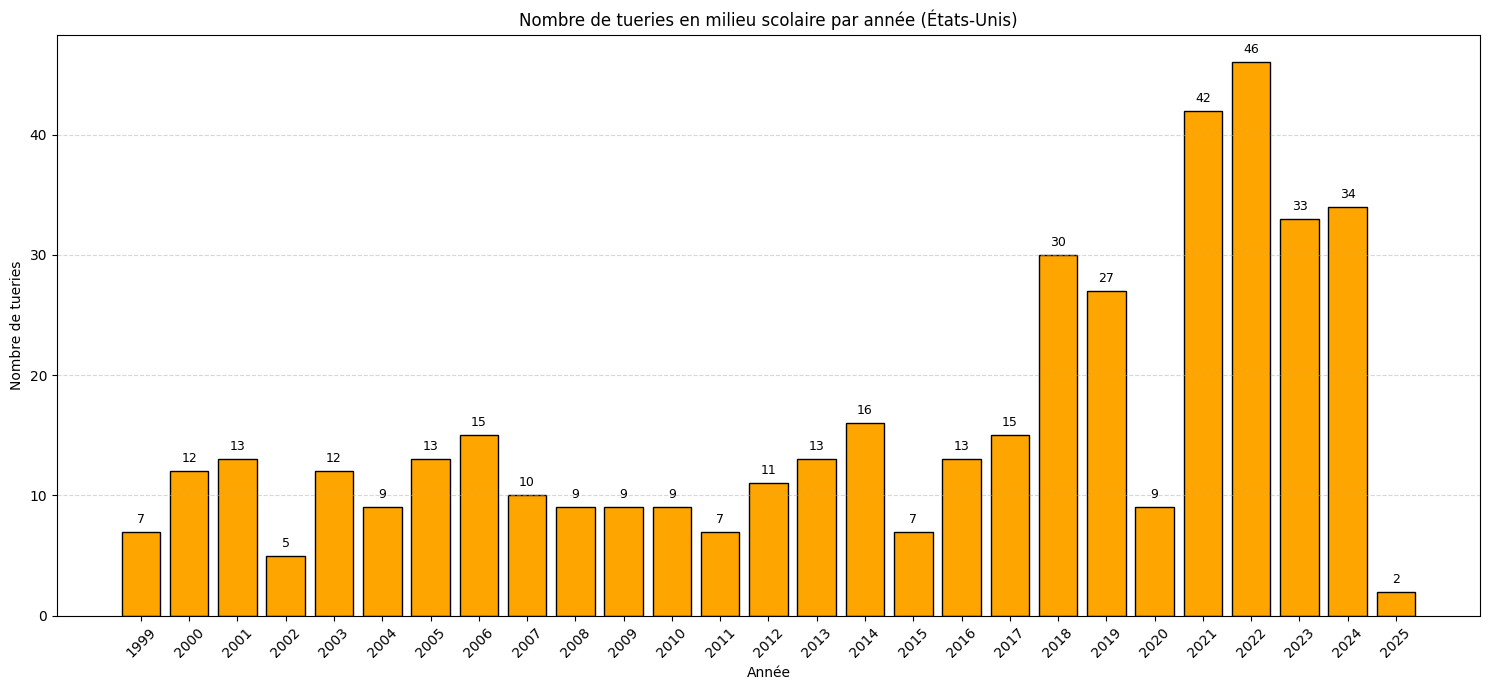

In [12]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
# 1. Connexion à la base de données
conn = sqlite3.connect('./data.db')
# 2. Requête SQL pour compter les tueries par année
# On utilise la colonne 'year' déjà présente dans la table school_shootings
query = """
SELECT
    year,
    COUNT(*) AS shooting_count
FROM school_shootings
WHERE year IS NOT NULL
GROUP BY year
ORDER BY year ASC
"""
# 3. Charger les données dans un DataFrame pandas
df = pd.read_sql_query(query, conn)
# 4. Création du graphique à barres
plt.figure(figsize=(15, 7))
bars = plt.bar(df['year'].astype(str), df['shooting_count'], color='orange', edgecolor='black')
 # Ajouter le nombre exact au-dessus de chaque barre
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, int(yval), ha='center', va='bottom', fontsize=9)
plt.xlabel('Année')
plt.ylabel('Nombre de tueries')
plt.title('Nombre de tueries en milieu scolaire par année (États-Unis)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
# Afficher le graphique
plt.show()
# Fermer la connexion
conn.close()

2021 a 2024 largement superieur a autre 2025 petit car dataset pas fini 

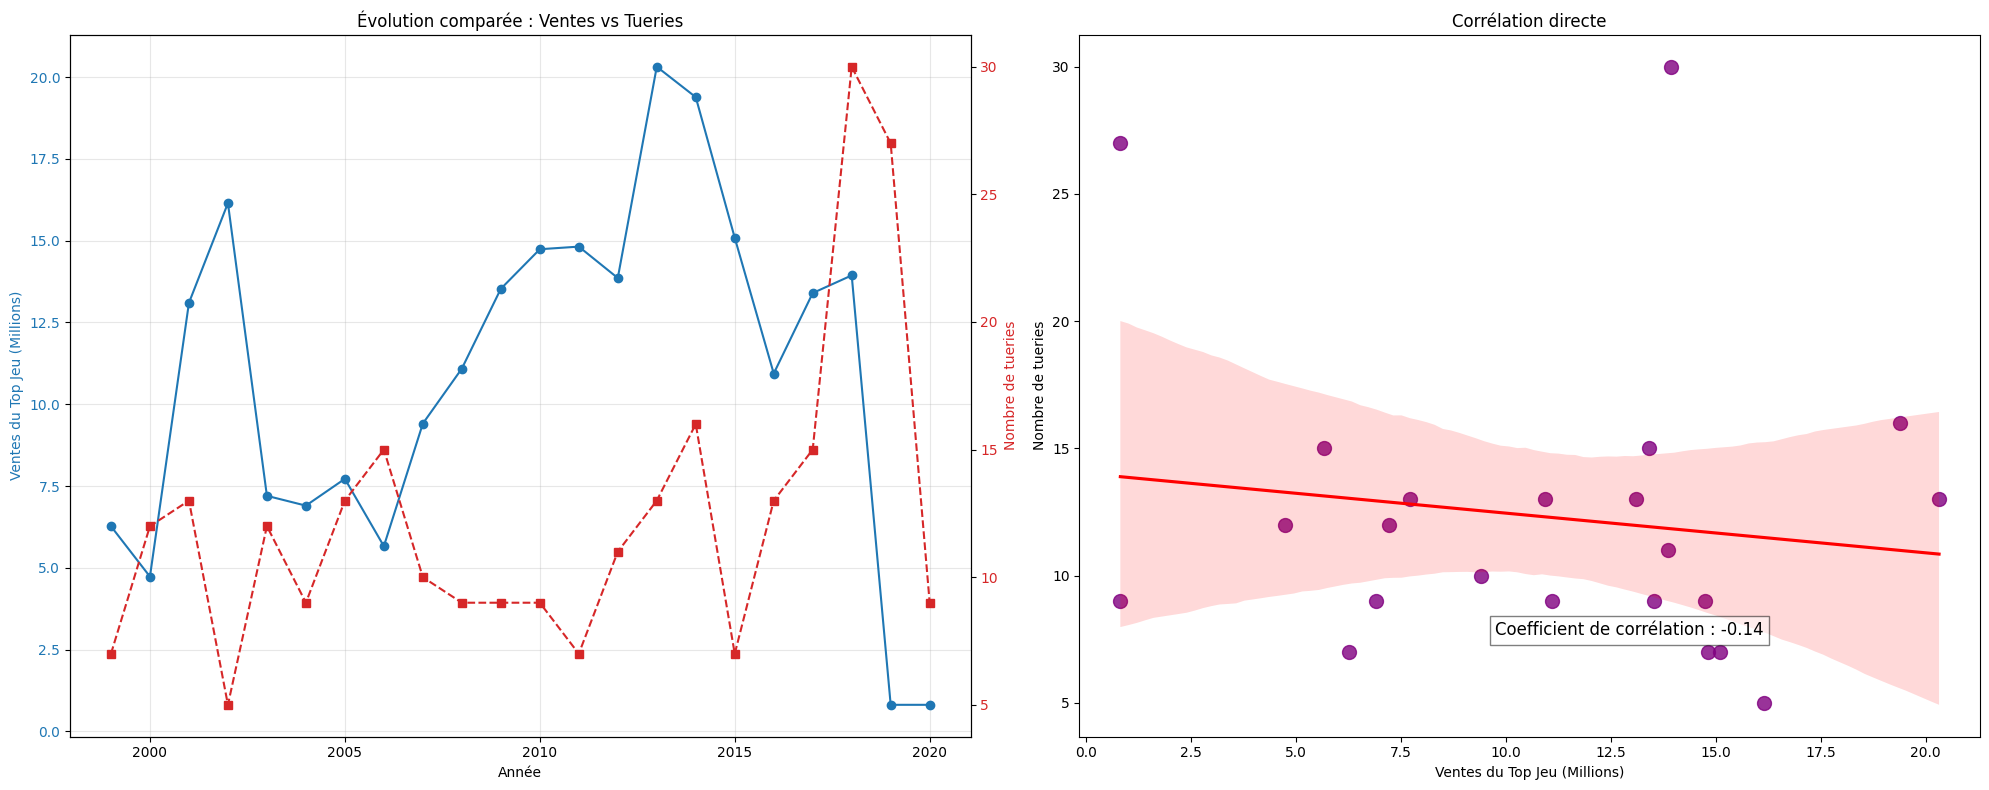

In [14]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Connexion à la base de données
conn = sqlite3.connect('./data.db')

# 2. Extraction des ventes (Top jeu par année)
query_vg = """
SELECT 
    CAST(strftime('%Y', release_date) AS INTEGER) AS year, 
    MAX(total_sales) AS top_game_sales
FROM video_games 
WHERE release_date IS NOT NULL AND total_sales IS NOT NULL
GROUP BY year
"""
df_vg = pd.read_sql_query(query_vg, conn)

# 3. Extraction des tueries par année
query_ss = """
SELECT
    year,
    COUNT(*) AS shooting_count
FROM school_shootings
WHERE year IS NOT NULL
GROUP BY year
"""
df_ss = pd.read_sql_query(query_ss, conn)
conn.close()

# 4. Fusion des données sur l'année
df_total = pd.merge(df_vg, df_ss, on='year')

# Filtrage sur la période demandée
df_total = df_total[(df_total['year'] >= 1999) & (df_total['year'] <= 2024)]

# 5. Création de la figure avec deux graphiques
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# --- GRAPHE 1 : Évolution temporelle (Double Axe) ---
color_vg = 'tab:blue'
ax1.set_xlabel('Année')
ax1.set_ylabel('Ventes du Top Jeu (Millions)', color=color_vg)
ax1.plot(df_total['year'], df_total['top_game_sales'], color=color_vg, marker='o', label='Ventes Jeu Record')
ax1.tick_params(axis='y', labelcolor=color_vg)

ax1_bis = ax1.twinx() # Création d'un deuxième axe Y
color_ss = 'tab:red'
ax1_bis.set_ylabel('Nombre de tueries', color=color_ss)
ax1_bis.plot(df_total['year'], df_total['shooting_count'], color=color_ss, marker='s', linestyle='--', label='Tueries')
ax1_bis.tick_params(axis='y', labelcolor=color_ss)

ax1.set_title('Évolution comparée : Ventes vs Tueries')
ax1.grid(True, alpha=0.3)

# --- GRAPHE 2 : Nuage de points (Corrélation) ---
sns.regplot(ax=ax2, x='top_game_sales', y='shooting_count', data=df_total, 
            scatter_kws={'s': 100, 'color': 'purple'}, line_kws={'color': 'red'})
ax2.set_title('Corrélation directe')
ax2.set_xlabel('Ventes du Top Jeu (Millions)')
ax2.set_ylabel('Nombre de tueries')

# Calcul du coefficient de corrélation de Pearson
corr_val = df_total['top_game_sales'].corr(df_total['shooting_count'])
plt.figtext(0.75, 0.2, f'Coefficient de corrélation : {corr_val:.2f}', 
            fontsize=12, bbox={'facecolor':'white', 'alpha':0.5})

plt.tight_layout()
plt.show()

pas vraiment de correlation 2015 peu de tuerie alors que le jeu le plus vendu et black ops 3 un jeu violent 2020 enormement de tuerie selon le dataset pas forcement complet pas un jeu violent le plus vendu plus le type de jeu le plus vendu et role_playing pas forcement de violence